Epoch 1/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8188 - loss: 0.3857 - val_accuracy: 0.8859 - val_loss: 0.2670
Epoch 2/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9536 - loss: 0.1393 - val_accuracy: 0.8842 - val_loss: 0.2771
Epoch 3/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9943 - loss: 0.0340 - val_accuracy: 0.8824 - val_loss: 0.3126
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8761 - loss: 0.3355
Accuracy: 0.8761000037193298


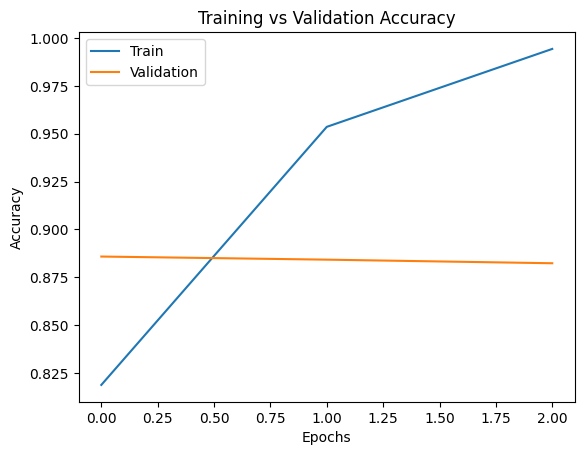

In [2]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset from CSV
data = pd.read_csv("imdb.csv")  # change name if needed

# Columns: review, sentiment
X = data['review']
y = data['sentiment'].map({'positive': 1, 'negative': 0})

# Train-test split
X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Convert text → sequences
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train_text)

X_train = tokenizer.texts_to_sequences(X_train_text)
X_test = tokenizer.texts_to_sequences(X_test_text)

# Pad sequences (same as your code)
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=200)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=200)

# Model (same)
model = keras.Sequential([
    layers.Embedding(10000, 128),
    layers.Flatten(),
    layers.Dense(1, activation='sigmoid')
])

# Compile (same)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train (same)
history = model.fit(X_train, y_train, epochs=3, validation_split=0.2)

# Evaluate (same)
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

# Plot Accuracy (same)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.show()